In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv("dataset_limpio.csv")
df.head()
df.info()
df.describe()

ModuleNotFoundError: No module named 'matplotlib'

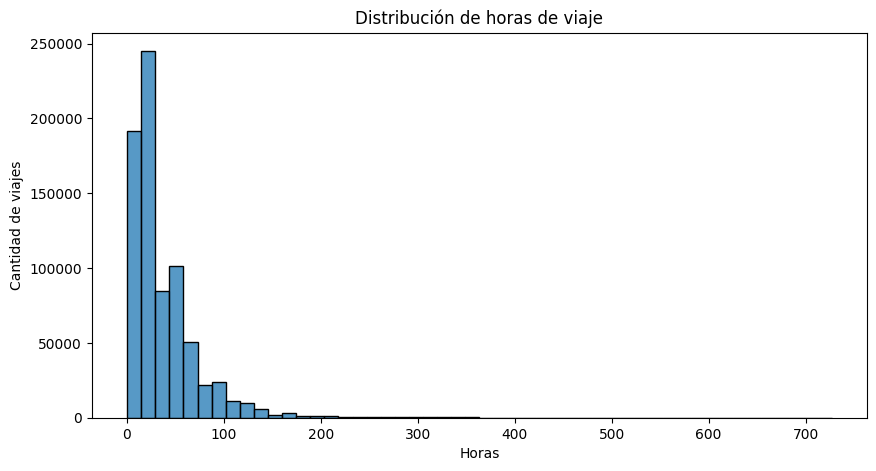

In [ ]:
#Distribución de las horas del viaje
plt.figure(figsize=(10,5))

sns.histplot(df["HORAS_VIAJE"], bins=50)

plt.title("Distribución de horas de viaje")
plt.xlabel("Horas")
plt.ylabel("Cantidad de viajes")

df["HORAS_VIAJE"].describe()
df["HORAS_VIAJE"].quantile([0.90, 0.95, 0.99])
df = df[df["HORAS_VIAJE"] <= 150]

plt.show()

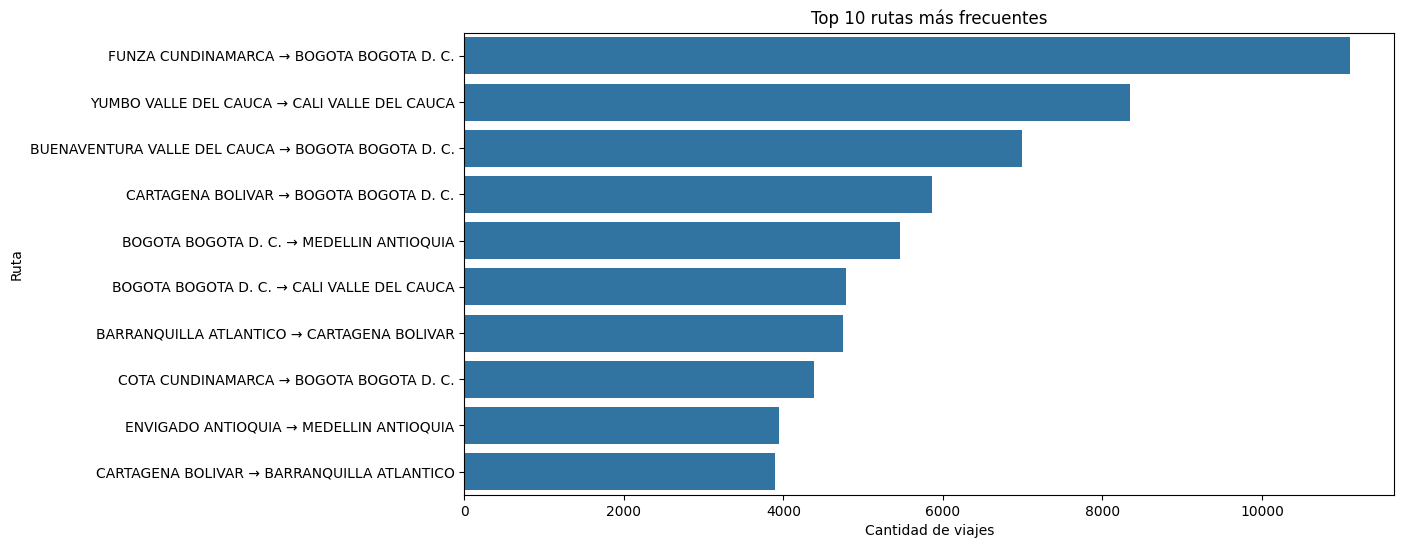

In [ ]:
rutas = (
    df.groupby(["CARGUE", "DESCARGUE"])
    .size()
    .reset_index(name="TOTAL")
)

rutas = rutas.sort_values(by="TOTAL", ascending=False)

rutas.head(10)

top_rutas = rutas.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_rutas["TOTAL"],
    y=top_rutas["CARGUE"] + " → " + top_rutas["DESCARGUE"]
)

plt.title("Top 10 rutas más frecuentes")
plt.xlabel("Cantidad de viajes")
plt.ylabel("Ruta")

plt.show()

C:\Users\Jhank\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Jhank\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


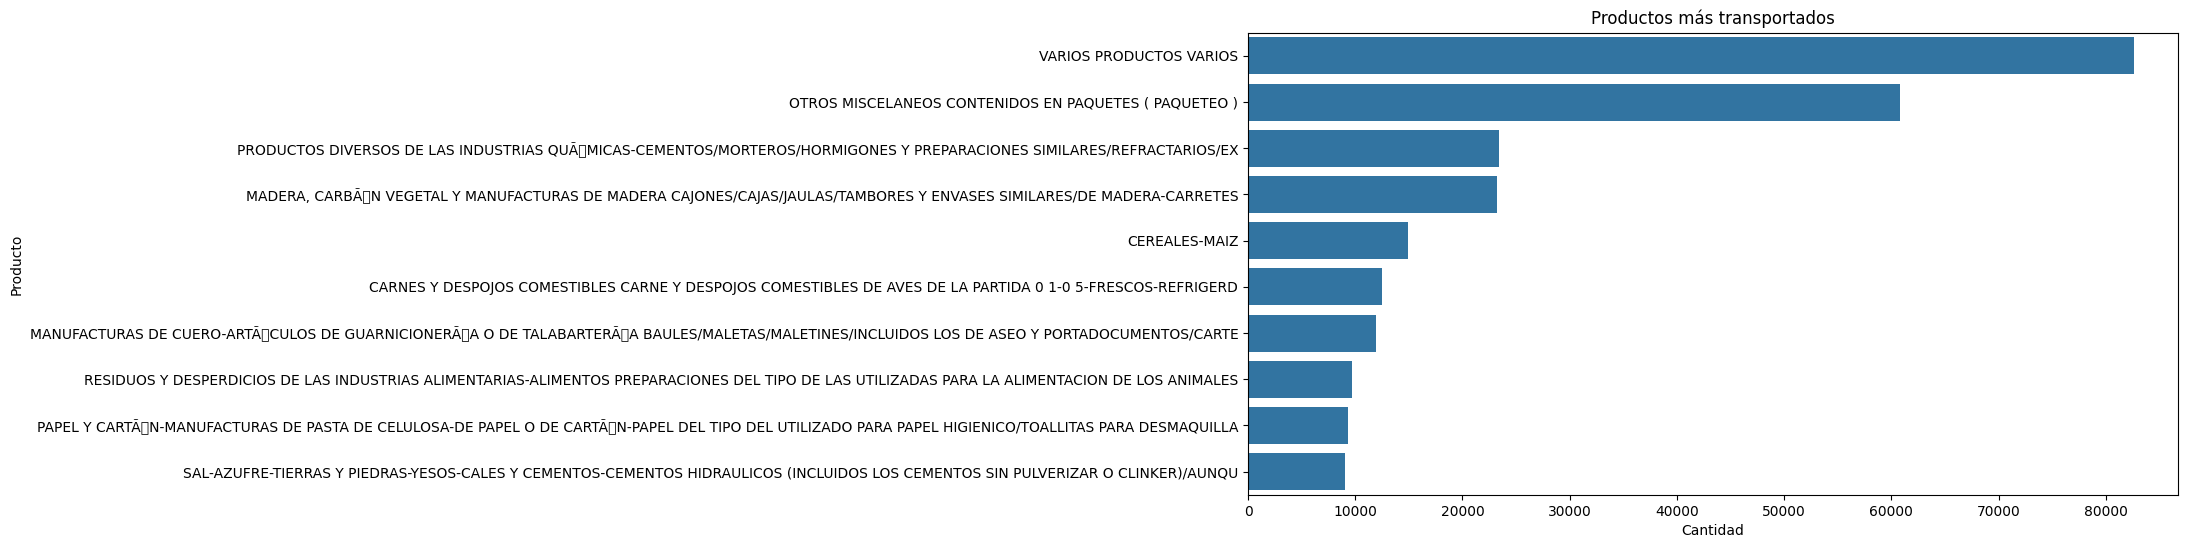

In [ ]:
top_productos = (
    df["PRODUCTO"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_productos.values,
    y=top_productos.index
)

plt.title("Productos más transportados")
plt.xlabel("Cantidad")
plt.ylabel("Producto")

plt.show()

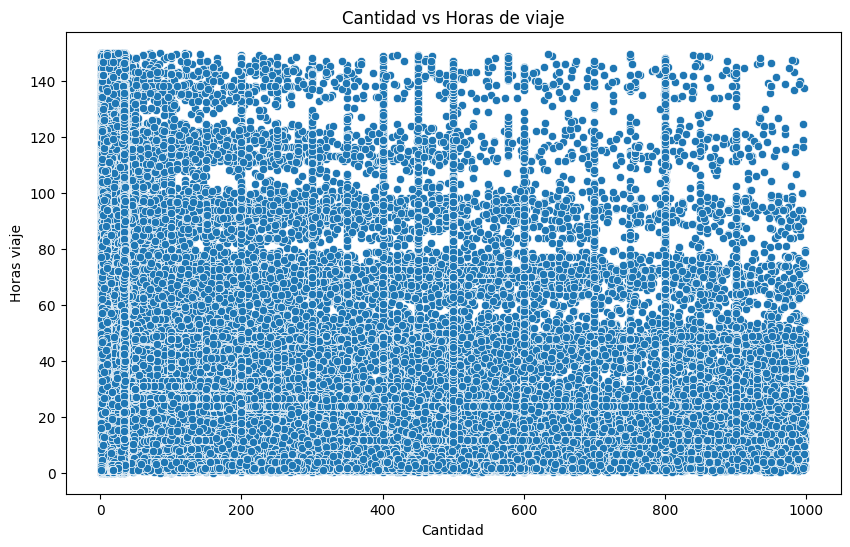

In [ ]:
df_filtrado = df[df["CANTIDAD"] < 10000]

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df_filtrado["CANTIDAD"],
    y=df_filtrado["HORAS_VIAJE"]
)

plt.title("Cantidad vs Horas de viaje")
plt.xlabel("Cantidad")
plt.ylabel("Horas viaje")

plt.show()

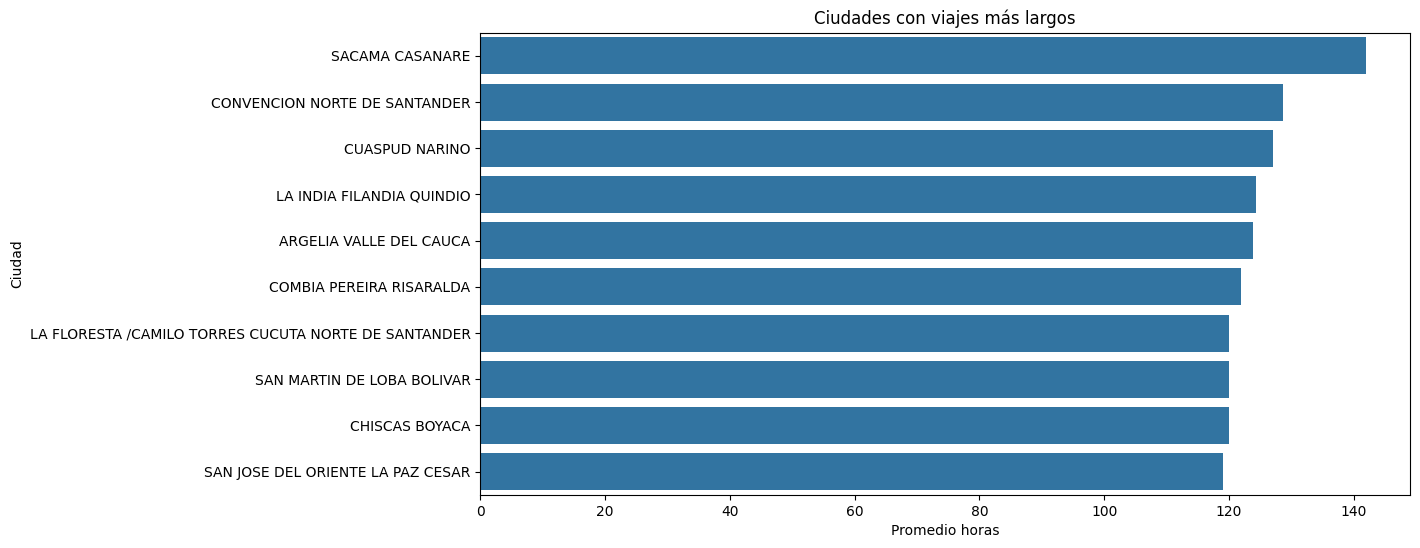

In [ ]:
promedio_ciudad = (
    df.groupby("CARGUE")["HORAS_VIAJE"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=promedio_ciudad.values,
    y=promedio_ciudad.index
)

plt.title("Ciudades con viajes más largos")
plt.xlabel("Promedio horas")
plt.ylabel("Ciudad")

plt.show()

c:\Users\Jhank\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 145 (\x91) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\Jhank\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 145 (\x91) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


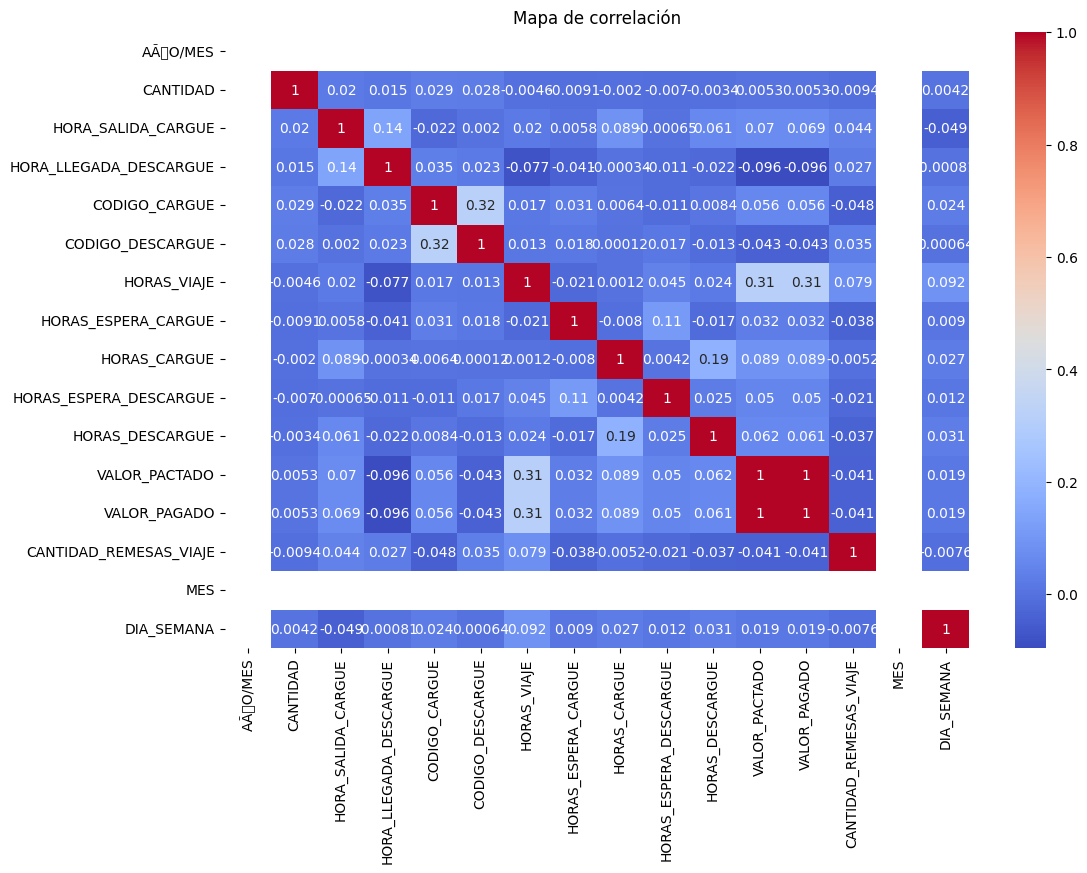

In [ ]:
#Correlaciones
numericas = df.select_dtypes(include=np.number)
#Matriz de correlación
correlacion = numericas.corr()
#Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm"
)

plt.title("Mapa de correlación")

plt.show()


C:\Users\Jhank\AppData\Local\Temp\ipykernel_21564\3436496783.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in modelo_df.select_dtypes(include='object').columns:


AÃO/MES                    int64
NATURALEZA                  int64
COD_PRODUCTO                int64
PRODUCTO                    int64
CANTIDAD                  float64
UNID_MEDIDA                 int64
HORA_SALIDA_CARGUE        float64
HORA_LLEGADA_DESCARGUE    float64
CODIGO_CARGUE               int64
CARGUE                      int64
CODIGO_DESCARGUE            int64
DESCARGUE                   int64
HORAS_VIAJE               float64
HORAS_ESPERA_CARGUE       float64
HORAS_CARGUE              float64
HORAS_ESPERA_DESCARGUE    float64
HORAS_DESCARGUE           float64
VALOR_PACTADO             float64
VALOR_PAGADO              float64
CANTIDAD_REMESAS_VIAJE      int64
MES                         int64
DIA_SEMANA                  int64
dtype: object
MAE: 8.096753547668522
RMSE: 14.792517537171875
R²: 0.7299133025603712
    Valor Real  Prediccion
0        95.00   87.750500
1        58.85   59.341400
2        38.00   46.344600
3         6.00    6.000000
4        44.00   26.120700
5    

C:\Users\Jhank\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 145 (\x91) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


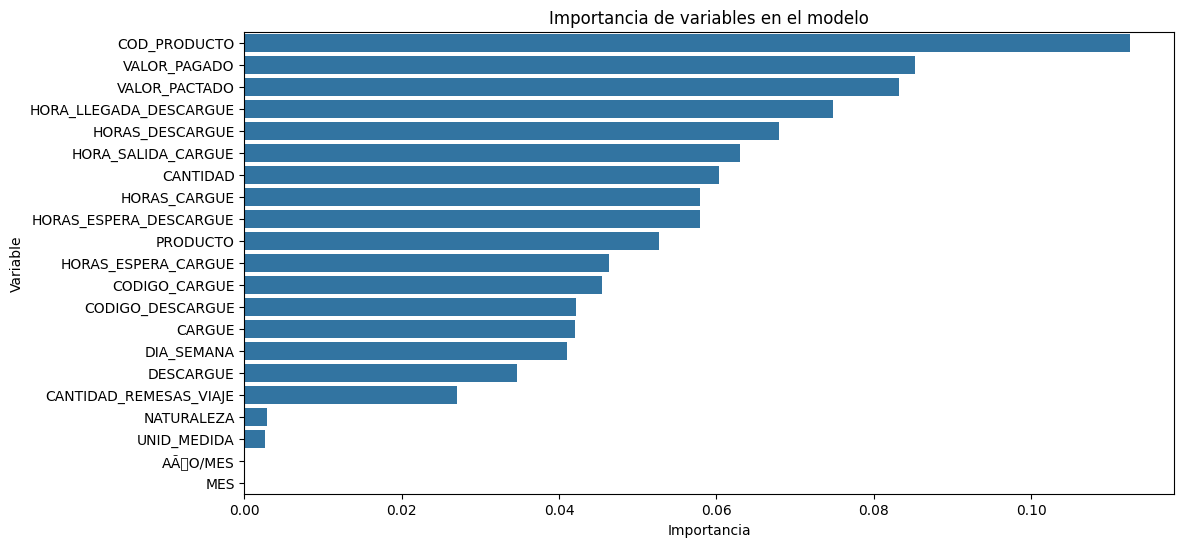

AÃO/MES                    int64
NATURALEZA                  int64
COD_PRODUCTO                int64
PRODUCTO                    int64
CANTIDAD                  float64
UNID_MEDIDA                 int64
HORA_SALIDA_CARGUE        float64
HORA_LLEGADA_DESCARGUE    float64
CODIGO_CARGUE               int64
CARGUE                      int64
CODIGO_DESCARGUE            int64
DESCARGUE                   int64
HORAS_ESPERA_CARGUE       float64
HORAS_CARGUE              float64
HORAS_ESPERA_DESCARGUE    float64
HORAS_DESCARGUE           float64
VALOR_PACTADO             float64
VALOR_PAGADO              float64
CANTIDAD_REMESAS_VIAJE      int64
MES                         int64
DIA_SEMANA                  int64
dtype: object

In [2]:
import pandas as pd
import numpy as np
import json
import base64
import pickle
import warnings
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

# =========================================================
# CONFIGURACIÓN (rutas de salida en JSON)
# =========================================================
ARCHIVO_DATASET = "dataset_limpio.csv"
MODELO_SALIDA = "modelo_tiempo.json"       # antes .pkl
ENCODERS_SALIDA = "label_encoders.json"    # antes .pkl

# =========================================================
# 1. CARGAR DATASET
# =========================================================
print("Cargando dataset...")
try:
    df = pd.read_csv(ARCHIVO_DATASET, encoding='utf-8')
except:
    try:
        df = pd.read_csv(ARCHIVO_DATASET, encoding='latin1')
    except:
        df = pd.read_csv(ARCHIVO_DATASET, encoding='iso-8859-1')

df.columns = df.columns.str.strip().str.upper()
print("Columnas detectadas:", df.columns.tolist())
print(f"Filas originales: {len(df)}")

# =========================================================
# 2. LIMPIEZA
# =========================================================
if 'HORAS_VIAJE' not in df.columns:
    print("ERROR: No se encontró la columna 'HORAS_VIAJE'")
    print("Columnas disponibles:", df.columns.tolist())
    raise KeyError("Columna HORAS_VIAJE no encontrada")

df = df.dropna(subset=["HORAS_VIAJE"])
print(f"Filas después de eliminar NaN en HORAS_VIAJE: {len(df)}")

# =========================================================
# 3. PREPARAR VARIABLES
# =========================================================
tiempo_df = df.copy()

columnas_eliminar = [
    "HORAS_VIAJE", "VALOR_PAGADO", "VALOR_PACTADO", 
    "FECHASALIDACARGUE", "FECHALLEGADADESCARGUE"
]
tiempo_df = tiempo_df.drop(columns=columnas_eliminar, errors="ignore")

# =========================================================
# 4. CODIFICAR VARIABLES CATEGÓRICAS
# =========================================================
print("Codificando variables categóricas...")
le_dict = {}

for col in tiempo_df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    tiempo_df[col] = le.fit_transform(tiempo_df[col].astype(str))
    le_dict[col] = le

# =========================================================
# 5. DEFINIR X e y
# =========================================================
X = tiempo_df
y = df["HORAS_VIAJE"]
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]
print(f"Filas finales usadas: {len(X)}")

# =========================================================
# 6. DIVISIÓN ENTRENAMIENTO / PRUEBA
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Entrenamiento: {len(X_train)} filas")
print(f"Prueba: {len(X_test)} filas")

# =========================================================
# 7. ENTRENAR MODELO
# =========================================================
print("Entrenando modelo Random Forest...")
modelo_tiempo = RandomForestRegressor(
    n_estimators=5,
    random_state=42,
    n_jobs=-1
)
modelo_tiempo.fit(X_train, y_train)
print("Modelo entrenado correctamente.")

# =========================================================
# 8. EVALUACIÓN
# =========================================================
predicciones = modelo_tiempo.predict(X_test)
r2 = r2_score(y_test, predicciones)
mae = mean_absolute_error(y_test, predicciones)
rmse = mean_squared_error(y_test, predicciones) ** 0.5

print("\n=========== RESULTADOS ===========")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# =========================================================
# 9. GUARDAR MODELO Y ENCODERS EN JSON (base64 + pickle)
# =========================================================

def serializar_a_json(objeto, ruta_json):
    """
    Convierte cualquier objeto de Python (modelo, encoder) a JSON
    codificándolo primero con pickle y luego base64.
    """
    # Serializar con pickle a bytes
    bytes_pickle = pickle.dumps(objeto)
    # Codificar a base64 (para que sea texto plano)
    b64_str = base64.b64encode(bytes_pickle).decode('utf-8')
    # Guardar en JSON con metadatos
    data = {
        "type": type(objeto).__name__,
        "data_b64": b64_str
    }
    with open(ruta_json, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=2)
    print(f"✅ Objeto guardado como JSON: {ruta_json}")

# Guardar modelo
serializar_a_json(modelo_tiempo, MODELO_SALIDA)

# Guardar diccionario de encoders
serializar_a_json(le_dict, ENCODERS_SALIDA)

print("\n✅ Modelo y encoders guardados correctamente en formato JSON.")
print(f"Archivo modelo: {MODELO_SALIDA}")
print(f"Archivo encoders: {ENCODERS_SALIDA}")

Cargando dataset...
Columnas detectadas: ['AÃ\x91O/MES', 'NATURALEZA', 'COD_PRODUCTO', 'PRODUCTO', 'CANTIDAD', 'UNID_MEDIDA', 'FECHASALIDACARGUE', 'HORA_SALIDA_CARGUE', 'FECHALLEGADADESCARGUE', 'HORA_LLEGADA_DESCARGUE', 'CODIGO_CARGUE', 'CARGUE', 'CODIGO_DESCARGUE', 'DESCARGUE', 'HORAS_VIAJE', 'HORAS_ESPERA_CARGUE', 'HORAS_CARGUE', 'HORAS_ESPERA_DESCARGUE', 'HORAS_DESCARGUE', 'VALOR_PACTADO', 'VALOR_PAGADO', 'CANTIDAD_REMESAS_VIAJE', 'MES', 'DIA_SEMANA']
Filas originales: 350000
Filas después de eliminar NaN en HORAS_VIAJE: 350000
Codificando variables categóricas...
Filas finales usadas: 349741
Entrenamiento: 279792 filas
Prueba: 69949 filas
Entrenando modelo Random Forest...


Modelo entrenado correctamente.

=========== RESULTADOS ===========
R²: 0.5753
MAE: 12.4943
RMSE: 24.7710
✅ Objeto guardado como JSON: modelo_tiempo.json
✅ Objeto guardado como JSON: label_encoders.json

✅ Modelo y encoders guardados correctamente en formato JSON.
Archivo modelo: modelo_tiempo.json
Archivo encoders: label_encoders.json
